In [21]:
import numpy as np
from enums.ScalingMethod import ScalingMethod
from enums.ResamplingMethod import ResamplingMethod
from model.LogisticRegressionModel import LogisticRegressionModel
from model.XGBoostModel import XGBoostModel
from model.ShallowNNModel import ShallowNNModel
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_theme()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Shallow NN

In [22]:
with_features = True
scaling_method = None
resampling_method = None

In [23]:
 # 1. Initialize model, scaler and resampler
scaler = dataset_service.get_scaler(method=scaling_method)
resampler = dataset_service.get_resampler(method=resampling_method)

print(scaler, resampler)

None None


## Centralized

In [32]:
x_all, y_all = dataset_service.get_subject_data(subject="all", with_features=with_features)
x_train, x_test, y_train, y_test = dataset_service.train_test_split(x=x_all, y=y_all)

In [33]:
model = ShallowNNModel(scaler=scaler, resampler=resampler, input_shape=x_train.shape[1])
model.fit(x_train=x_train, y_train=y_train, run_info=dict())

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Epoch 1/150
Epoch 1/150
Epoch 1/150
Epoch 1/150
Epoch 1/150
2166/2166 - 10s - 5ms/step - accuracy: 0.6917 - loss: 0.5553 - val_accuracy: 0.6324 - val_loss: 0.7093 - learning_rate: 0.0010
Epoch 2/150
2166/2166 - 10s - 5ms/step - accuracy: 0.6911 - loss: 0.5618 - val_accuracy: 0.5303 - val_loss: 0.7304 - learning_rate: 0.0010
Epoch 2/150
2166/2166 - 10s - 5ms/step - accuracy: 0.6875 - loss: 0.5593 - val_accuracy: 0.6471 - val_loss: 0.6123 - learning_rate: 0.0010
Epoch 2/150
2166/2166 - 10s - 5ms/step - accuracy: 0.6812 - loss: 0.5672 - val_accuracy: 0.6759 - val_loss: 0.6815 - learning_rate: 0.0010
Epoch 2/150
2166/2166 - 10s - 5ms/step - accuracy: 0.6900 - loss: 0.5573 - val_accuracy: 0.7313 - val_loss: 0.5409 - learning_rate: 0.0010
Epoch 2/150
2166/2166 - 10s - 4ms/step - accuracy: 0.7727 - loss: 0.4547 - val_accuracy: 0.7940 - val_loss: 0.4195 - learning_rate: 0.0010
Epoch 3/150
2166/2166 - 10s - 4ms/step - accuracy: 0.7771 -

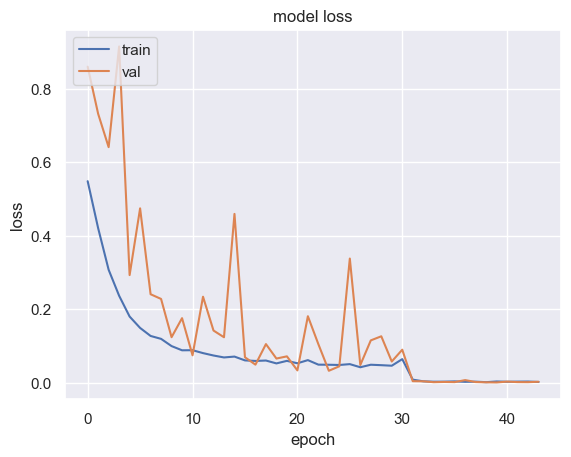

In [34]:
history = model.get_fitted_model().named_steps["clf"].history_

plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [55]:
x_all, y_all = dataset_service.get_subject_data(subject=19, with_features=with_features)
_, x_test_2, _, y_test_2 = dataset_service.train_test_split(x=x_all, y=y_all)
pred_test = model.predict(x=x_test_2)
scores_test, _ = model.evaluate(pred=pred_test, y_true=y_test_2)
print(scores_test)

18/18 - 0s - 2ms/step
{'accuracy': 1.0, 'recall': 1.0, 'precision': 1.0, 'f1': 1.0, 'confusion_matrix': {'tp': 150, 'tn': 405, 'fp': 0, 'fn': 0}}


## Individual

In [24]:
f1_scores = list()
for subject in range(2, 36):
    x_all, y_all = dataset_service.get_subject_data(subject=subject, with_features=with_features)
    x_train, x_test, y_train, y_test = dataset_service.train_test_split(x=x_all, y=y_all)

    model = ShallowNNModel(scaler=scaler, resampler=resampler, input_shape=x_train.shape[1])
    model.fit(x_train=x_train, y_train=y_train, run_info=dict())

    pred_test = model.predict(x=x_test)
    scores_test, _ = model.evaluate(pred=pred_test, y_true=y_test)
    f1_scores.append(scores_test["f1"])

print(np.average(f1_scores))

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Epoch 1/150
Epoch 1/150
Epoch 1/150
Epoch 1/150
Epoch 1/150
51/51 - 1s - 19ms/step - accuracy: 0.6451 - loss: 1.0581 - val_accuracy: 0.7444 - val_loss: 0.5452 - learning_rate: 0.0010
Epoch 2/150
51/51 - 1s - 19ms/step - accuracy: 0.6389 - loss: 1.0083 - val_accuracy: 0.7146 - val_loss: 0.6792 - learning_rate: 0.0010
51/51 - 1s - 19ms/step - accuracy: 0.6433 - loss: 0.9946 - val_accuracy: 0.7345 - val_loss: 0.5588 - learning_rate: 0.0010
Epoch 2/150
Epoch 2/150
51/51 - 1s - 19ms/step - accuracy: 0.6594 - loss: 0.9699 - val_accuracy: 0.7270 - val_loss: 0.5510 - learning_rate: 0.0010
Epoch 2/150
51/51 - 1s - 19ms/step - accuracy: 0.6495 - loss: 1.0181 - val_accuracy: 0.7047 - val_loss: 0.6899 - learning_rate: 0.0010
Epoch 2/150
51/51 - 0s - 5ms/step - accuracy: 0.7228 - loss: 0.5798 - val_accuracy: 0.7246 - val_loss: 0.5799 - learning_rate: 0.0010
Epoch 3/150
51/51 - 0s - 5ms/step - accuracy: 0.7520 - loss: 0.5548 - val_accuracy: 

2025-02-06 11:21:23.448549: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Incompatible shapes: [64,50] vs. [0]
	 [[{{function_node __inference_one_step_on_data_362142}}{{node adam/truediv_17}}]]


45/45 - 1s - 19ms/step - accuracy: 0.5854 - loss: 1.3134 - val_accuracy: 0.3601 - val_loss: 0.7774 - learning_rate: 0.0010
Epoch 2/150
46/46 - 1s - 19ms/step - accuracy: 0.6190 - loss: 1.0058 - val_accuracy: 0.5208 - val_loss: 0.6882 - learning_rate: 0.0010
Epoch 2/150
45/45 - 0s - 5ms/step - accuracy: 0.6222 - loss: 0.6691 - val_accuracy: 0.6565 - val_loss: 0.6157 - learning_rate: 0.0010
Epoch 3/150
46/46 - 0s - 5ms/step - accuracy: 0.5829 - loss: 0.7930 - val_accuracy: 0.6371 - val_loss: 0.6471 - learning_rate: 0.0010
Epoch 3/150
45/45 - 1s - 19ms/step - accuracy: 0.6042 - loss: 1.2011 - val_accuracy: 0.6371 - val_loss: 0.6699 - learning_rate: 0.0010
Epoch 2/150
46/46 - 1s - 27ms/step - accuracy: 0.6114 - loss: 1.1021 - val_accuracy: 0.3712 - val_loss: 3.0746 - learning_rate: 0.0010
Epoch 2/150
45/45 - 0s - 4ms/step - accuracy: 0.6764 - loss: 0.6017 - val_accuracy: 0.6537 - val_loss: 0.5990 - learning_rate: 0.0010
Epoch 4/150
45/45 - 0s - 4ms/step - accuracy: 0.6278 - loss: 0.6918 - 

/Users/cedric/miniconda3/envs/project_2/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
1 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/cedric/miniconda3/envs/project_2/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/cedric/miniconda3/envs/project_2/lib/python3.10/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/cedric/miniconda3/envs/project_2/lib/python3.10/site-packages/imblearn/pipeline

Epoch 1/150
57/57 - 1s - 13ms/step - accuracy: 0.5891 - loss: 1.0361 - val_accuracy: 0.6075 - val_loss: 0.6471 - learning_rate: 0.0010
Epoch 2/150
57/57 - 0s - 3ms/step - accuracy: 0.6341 - loss: 0.6629 - val_accuracy: 0.6497 - val_loss: 0.6228 - learning_rate: 0.0010
Epoch 3/150
57/57 - 0s - 3ms/step - accuracy: 0.6757 - loss: 0.5859 - val_accuracy: 0.6452 - val_loss: 0.5921 - learning_rate: 0.0010
Epoch 4/150
57/57 - 0s - 3ms/step - accuracy: 0.6968 - loss: 0.5628 - val_accuracy: 0.6630 - val_loss: 0.5865 - learning_rate: 0.0010
Epoch 5/150
57/57 - 0s - 3ms/step - accuracy: 0.7229 - loss: 0.5249 - val_accuracy: 0.6918 - val_loss: 0.5515 - learning_rate: 0.0010
Epoch 6/150
57/57 - 0s - 3ms/step - accuracy: 0.7529 - loss: 0.4951 - val_accuracy: 0.7361 - val_loss: 0.5116 - learning_rate: 0.0010
Epoch 7/150
57/57 - 0s - 3ms/step - accuracy: 0.7662 - loss: 0.4721 - val_accuracy: 0.7672 - val_loss: 0.4738 - learning_rate: 0.0010
Epoch 8/150
57/57 - 0s - 3ms/step - accuracy: 0.7951 - loss: 

2025-02-06 11:21:56.982878: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Incompatible shapes: [0] vs. [128,64]
	 [[{{function_node __inference_one_step_on_data_479014}}{{node adam/truediv_13}}]]


51/51 - 1s - 20ms/step - accuracy: 0.6338 - loss: 1.1624 - val_accuracy: 0.6824 - val_loss: 0.5713 - learning_rate: 0.0010
Epoch 2/150
51/51 - 1s - 19ms/step - accuracy: 0.6406 - loss: 1.0453 - val_accuracy: 0.6898 - val_loss: 0.9445 - learning_rate: 0.0010
Epoch 2/150
51/51 - 1s - 19ms/step - accuracy: 0.6425 - loss: 1.1384 - val_accuracy: 0.6948 - val_loss: 0.6566 - learning_rate: 0.0010
Epoch 2/150
51/51 - 1s - 20ms/step - accuracy: 0.6390 - loss: 1.1099 - val_accuracy: 0.6625 - val_loss: 0.6290 - learning_rate: 0.0010
Epoch 2/150
51/51 - 0s - 4ms/step - accuracy: 0.7008 - loss: 0.5989 - val_accuracy: 0.6824 - val_loss: 0.5705 - learning_rate: 0.0010
Epoch 3/150
51/51 - 0s - 4ms/step - accuracy: 0.6859 - loss: 0.6180 - val_accuracy: 0.6898 - val_loss: 0.5661 - learning_rate: 0.0010
Epoch 3/150
51/51 - 0s - 4ms/step - accuracy: 0.7107 - loss: 0.5722 - val_accuracy: 0.6948 - val_loss: 0.5570 - learning_rate: 0.0010
Epoch 3/150
51/51 - 0s - 4ms/step - accuracy: 0.6681 - loss: 0.6691 - 

/Users/cedric/miniconda3/envs/project_2/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
1 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/cedric/miniconda3/envs/project_2/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/cedric/miniconda3/envs/project_2/lib/python3.10/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/cedric/miniconda3/envs/project_2/lib/python3.10/site-packages/imblearn/pipeline

Epoch 1/150
63/63 - 1s - 12ms/step - accuracy: 0.6341 - loss: 1.0762 - val_accuracy: 0.5933 - val_loss: 0.6463 - learning_rate: 0.0010
Epoch 2/150
63/63 - 0s - 3ms/step - accuracy: 0.7016 - loss: 0.5848 - val_accuracy: 0.6468 - val_loss: 0.6042 - learning_rate: 0.0010
Epoch 3/150
63/63 - 0s - 3ms/step - accuracy: 0.7175 - loss: 0.5212 - val_accuracy: 0.7758 - val_loss: 0.4517 - learning_rate: 0.0010
Epoch 4/150
63/63 - 0s - 3ms/step - accuracy: 0.7587 - loss: 0.4752 - val_accuracy: 0.7937 - val_loss: 0.4378 - learning_rate: 0.0010
Epoch 5/150
63/63 - 0s - 3ms/step - accuracy: 0.7721 - loss: 0.4564 - val_accuracy: 0.7579 - val_loss: 0.4656 - learning_rate: 0.0010
Epoch 6/150
63/63 - 0s - 3ms/step - accuracy: 0.7825 - loss: 0.4409 - val_accuracy: 0.7917 - val_loss: 0.4250 - learning_rate: 0.0010
Epoch 7/150
63/63 - 0s - 3ms/step - accuracy: 0.7865 - loss: 0.4277 - val_accuracy: 0.8036 - val_loss: 0.3966 - learning_rate: 0.0010
Epoch 8/150
63/63 - 0s - 3ms/step - accuracy: 0.7865 - loss: 

# Logistic Regression

In [1]:
with_features = True
scaling_method = None
resampling_method = None

In [2]:
# 1. Initialize model, scaler and resampler
scaler = dataset_service.get_scaler(method=scaling_method)
resampler = dataset_service.get_resampler(method=resampling_method)

print(scaler, resampler)

NameError: name 'dataset_service' is not defined

## Centralized

In [10]:
x_all, y_all = dataset_service.get_subject_data(subject="all", with_features=with_features)
x_train, x_test, y_train, y_test = dataset_service.train_test_split(x=x_all, y=y_all)

In [12]:
model = LogisticRegressionModel(scaler=scaler, resampler=resampler)
model.fit(x_train=x_train, y_train=y_train, run_info=dict())

Fitting 5 folds for each of 1 candidates, totalling 5 fits


In [13]:
pred_test = model.predict(x=x_test)
scores_test, _ = model.evaluate(pred=pred_test, y_true=y_test)
print(scores_test)

{'accuracy': 0.6161970043158161, 'recall': 0.427159209157128, 'precision': 0.6665043026465335, 'f1': 0.520641765489251, 'confusion_matrix': {'tp': 4105, 'tn': 8031, 'fp': 5505, 'fn': 2054}}


## Individual

In [30]:
f1_scores = list()
for subject in range(2, 36):
    x_all, y_all = dataset_service.get_subject_data(subject=subject, with_features=with_features)
    x_train, x_test, y_train, y_test = dataset_service.train_test_split(x=x_all, y=y_all)

    model = LogisticRegressionModel(scaler=scaler, resampler=resampler)
    model.fit(x_train=x_train, y_train=y_train, run_info=dict())

    pred_test = model.predict(x=x_test)
    scores_test, _ = model.evaluate(pred=pred_test, y_true=y_test)
    f1_scores.append(scores_test["f1"])

print(np.average(f1_scores))

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

# XGBoost

In [25]:
with_features = True
scaling_method = None
resampling_method = None

In [26]:
# 1. Initialize model, scaler and resampler
scaler = dataset_service.get_scaler(method=scaling_method)
resampler = dataset_service.get_resampler(method=resampling_method)

print(scaler, resampler)

None None


## Centralized

In [15]:
x_all, y_all = dataset_service.get_subject_data(subject="all", with_features=with_features)
x_train, x_test, y_train, y_test = dataset_service.train_test_split(x=x_all, y=y_all)

In [17]:
model = XGBoostModel(scaler=scaler, resampler=resampler)
model.fit(x_train=x_train, y_train=y_train, run_info=dict())

Fitting 5 folds for each of 3 candidates, totalling 15 fits


In [18]:
pred_test = model.predict(x=x_test)
scores_test, _ = model.evaluate(pred=pred_test, y_true=y_test)
print(scores_test)

{'accuracy': 0.9992383853769993, 'recall': 0.9993498049414824, 'precision': 0.9982139957785354, 'f1': 0.99878157745106, 'confusion_matrix': {'tp': 6148, 'tn': 13532, 'fp': 4, 'fn': 11}}


## Individual

In [27]:
f1_scores = list()
for subject in range(2, 36):
    x_all, y_all = dataset_service.get_subject_data(subject=subject, with_features=with_features)
    x_train, x_test, y_train, y_test = dataset_service.train_test_split(x=x_all, y=y_all)

    model = XGBoostModel(scaler=scaler, resampler=resampler)
    model.fit(x_train=x_train, y_train=y_train, run_info=dict())

    pred_test = model.predict(x=x_test)
    scores_test, _ = model.evaluate(pred=pred_test, y_true=y_test)
    f1_scores.append(scores_test["f1"])

print(np.average(f1_scores))

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates